In [12]:
# compile results
import pickle

homedir = "/mnt/mirabelle/az6922_homedir/"
cm_list = ["unv1","prv1","cluster_a","cluster_b","cluster_c"]
load_list_dict = dict()
load_list_dict["unv1"] = range(1,11)
load_list_dict["prv1"] = range(1,11)
load_list_dict["cluster_a"] = range(3,31,3)
load_list_dict["cluster_b"] = range(4,41,4)
load_list_dict["cluster_c"] = range(5,51,5)
all_load_list_dict = load_list_dict # have no meaning here, just too lazy to change
# all_load_list_dict = dict()
# all_load_list_dict["unv1"] = range(1,11)
# all_load_list_dict["prv1"] = range(1,11)
# all_load_list_dict["cluster_a"] = range(3,31,3)
# all_load_list_dict["cluster_b"] = [10,30,50]
seed_list = [1,2,3,4,5]
scheme_list = ["dringsu2","leafspine","df2augalg","rrgsu2","dringecmp","dringfatpaths","dringfhi","dringracke1"]

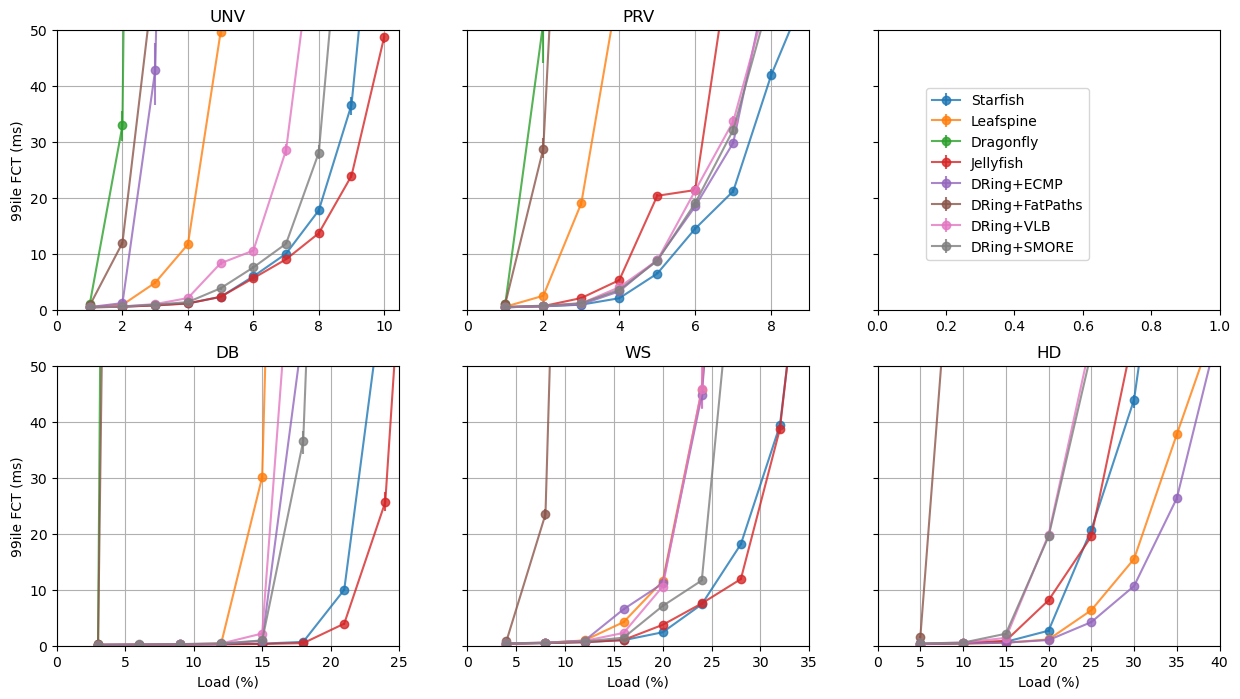

In [18]:
# plot from txt instead of pickle -- pickle files are too large
import matplotlib.pyplot as plt
import numpy as np

plotdatadict = dict()
sumfile = "fct_summary.txt"
with open(sumfile,'r') as f:
    # cluster_a/outfiles/rrgsu2_load6_seed2.out	0.05765561435997601	0.0487378	0.169153	0.746218
    lines = f.readlines()
    for line in lines:
        tokens = line.split()
        outfile = tokens[0]
        outfiletokens = outfile.split('/')
        cm = outfiletokens[0]
        avg = float(tokens[1])
        p50 = float(tokens[2])
        p99 = float(tokens[3])
        p9999 = float(tokens[4])

        if cm not in plotdatadict:
            plotdatadict[cm] = dict()
        plotdatadict[cm][outfile] = p99

plottitledict = {"unv1":"UNV","prv1":"PRV","cluster_a":"DB","cluster_b":"WS","cluster_c":"HD"}
plotirdict = {"unv1":0,"prv1":0,"cluster_a":1,"cluster_b":1,"cluster_c":1}
ploticdict = {"unv1":0,"prv1":1,"cluster_a":0,"cluster_b":1,"cluster_c":2}
plotlabeldict = {"dringsu2":"Starfish","leafspine":"Leafspine","df2augalg":"Dragonfly","rrgsu2":"Jellyfish","dringecmp":"DRing+ECMP","dringfatpaths":"DRing+FatPaths","dringfhi":"DRing+VLB","dringracke1":"DRing+SMORE"}
plotxlimdict = {"unv1":None,"prv1":9,"cluster_a":25,"cluster_b":35,"cluster_c":40}
nr = 2 #1
nc = 3 # len(cm_list)
fig, axs =plt.subplots(nr, nc, figsize=(nc*5, nr*4),sharey=True)
for cm in cm_list:
    ic = ploticdict[cm]
    ir = plotirdict[cm]
    for isc,scheme in enumerate(scheme_list):
        # if f"{cm}/outfiles/{scheme}_load{load_list_dict[cm][0]}_seed{seed_list[0]}.out" in plotdatadict[cm]:
            fct_list = list()
            for load in load_list_dict[cm]:
                fct_list_allseeds = list()
                for seed in seed_list:
                    outfile = f"{cm}/outfiles/{scheme}_load{load}_seed{seed}.out"
                    p99 = plotdatadict[cm][outfile]
                    fct_list_allseeds.append(p99)
                fct_list.append(fct_list_allseeds)
            if ic==0 and ir==0:
                axs[ir,ic].errorbar(load_list_dict[cm], [sum(x)/len(x) for x in fct_list], yerr=[[sum(x)/len(x)-min(x) for x in fct_list],[max(x)-sum(x)/len(x) for x in fct_list]], marker=markerlist[isc//10], label=plotlabeldict[scheme],alpha=0.8)
            else:
                axs[ir,ic].errorbar(load_list_dict[cm], [sum(x)/len(x) for x in fct_list], yerr=[[sum(x)/len(x)-min(x) for x in fct_list],[max(x)-sum(x)/len(x) for x in fct_list]], marker=markerlist[isc//10],alpha=0.8)

    axs[1,ic].set_xlabel("Load (%)")
    axs[ir,0].set_ylabel("99ile FCT (ms)")
    axs[ir,ic].set_ylim(0,50)
    axs[ir,ic].set_xlim(0,plotxlimdict[cm])
    axs[ir,ic].set_title(plottitledict[cm])
    axs[ir,ic].grid(True)
fig.legend(loc='center left', bbox_to_anchor=(0.7, 0.7))